<a href="https://colab.research.google.com/github/Thummanapallykarthik/NLP/blob/main/assignment13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import re
import string

# 1. Load the dataset
df = pd.read_csv('spam (1).csv', encoding='latin-1')

# Cleanup columns
df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})

# 2. Text Preprocessing Function
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()
    # Remove punctuation and special characters
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
    # Remove extra whitespace
    text = " ".join(text.split())
    return text

# Apply preprocessing
df['cleaned_text'] = df['text'].apply(clean_text)

# Display sample output
print(df[['label', 'cleaned_text']].head())

# Save to CSV
df.to_csv('cleaned_spam_data.csv', index=False)

  label                                       cleaned_text
0   ham  go until jurong point crazy available only in ...
1   ham                            ok lar joking wif u oni
2  spam  free entry in 2 a wkly comp to win fa cup fina...
3   ham        u dun say so early hor u c already then say
4   ham  nah i dont think he goes to usf he lives aroun...


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# 1. Feature Extraction using TF-IDF
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['cleaned_text'])
y = df['label']

# 2. Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Model Implementation
model = MultinomialNB()
model.fit(X_train, y_train)

# 4. Model Evaluation
y_pred = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.96
              precision    recall  f1-score   support

         ham       0.95      1.00      0.98       965
        spam       1.00      0.68      0.81       150

    accuracy                           0.96      1115
   macro avg       0.98      0.84      0.89      1115
weighted avg       0.96      0.96      0.95      1115



Accuracy: 0.9570
Precision: 1.0000
Recall: 0.6800
F1-score: 0.8095


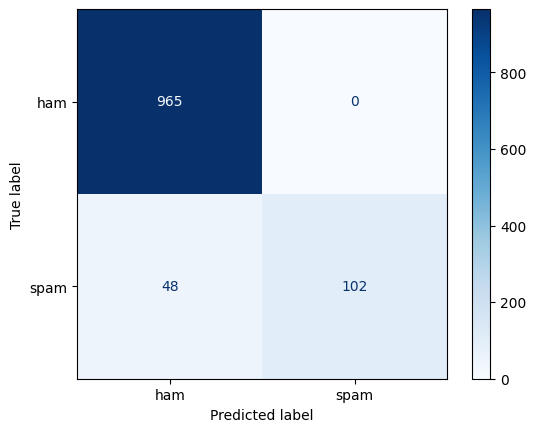

In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on test data
y_pred = model.predict(X_test)

# Calculate metrics
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, pos_label='spam'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred, pos_label='spam'):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred, pos_label='spam'):.4f}")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

# count vectiorization

In [4]:
import pandas as pd
import re
import string

# 1. Load the dataset
df = pd.read_csv('spam (1).csv', encoding='latin-1')
df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})

# 2. Text Preprocessing function
def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and special characters
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
    # Remove extra whitespace
    text = " ".join(text.split())
    return text

# Apply preprocessing
df['cleaned_text'] = df['text'].apply(clean_text)

# Save to CSV
df.to_csv('cleaned_spam_data.csv', index=False)

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

# 4. Feature Extraction using CountVectorizer
cv = CountVectorizer()
X = cv.fit_transform(df['cleaned_text'])
y = df['label']

# 5. Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. Model Implementation & Training
model = MultinomialNB()
model.fit(X_train, y_train)

# Output basic information
print(f"Total vocabulary size: {len(cv.get_feature_names_out())}")
print(f"Training samples: {X_train.shape[0]}")
print("Model training complete.")

Total vocabulary size: 9489
Training samples: 4457
Model training complete.


Accuracy: 0.9785
Precision: 0.9200
Recall: 0.9200
F1-score: 0.9200


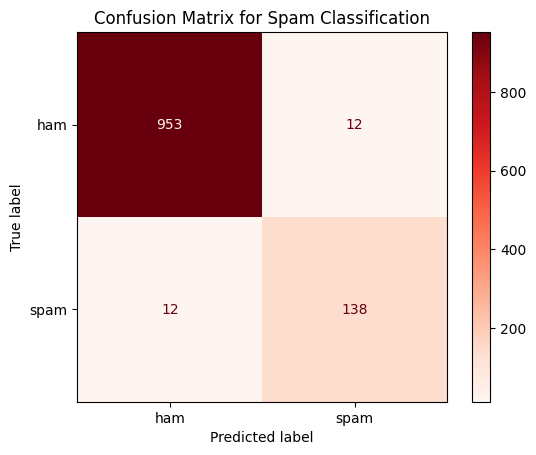

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 5. Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. Model Implementation & Training
model = MultinomialNB()
model.fit(X_train, y_train)

# 7. Model Evaluation
# Predict labels for the test data
y_pred = model.predict(X_test)

# Calculate metrics for the 'spam' class
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, pos_label='spam'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred, pos_label='spam'):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred, pos_label='spam'):.4f}")

# Generate and plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Reds')
plt.title('Confusion Matrix for Spam Classification')
plt.show()